In [1]:
# PERFORMING EDA ON THIS FASHION DATASET

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns 
import gradio as gr 
import json
import os
import re
import numpy as np
import pandas as pd
import faiss
 
# Advanced ML Processing and Predictive Evaluation Core
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder 
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline 
from datetime import datetime
from graphviz import Digraph
from sklearn.impute import SimpleImputer 
from sklearn.ensemble import RandomForestRegressor 
from sentence_transformers import SentenceTransformer
from transformers import logging 
logging.set_verbosity_error()

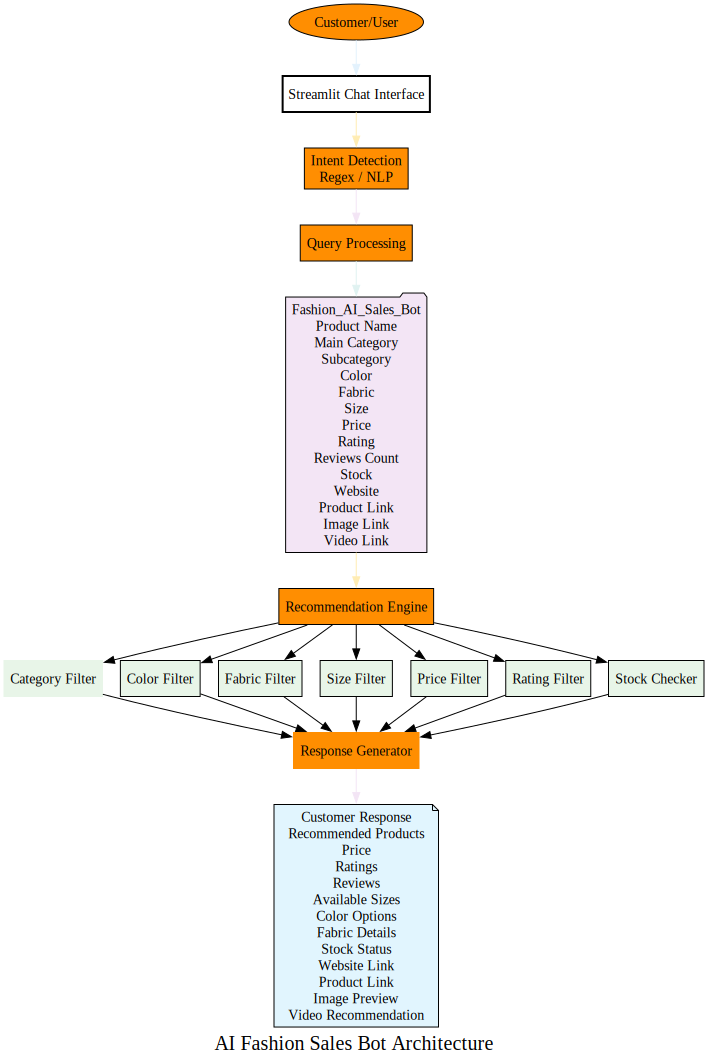

In [3]:

# GRAPHVIZ PATH 
os.environ["PATH"]+=os.pathsep+r"C:\Users\User\Downloads\windows_10_cmake_Release_Graphviz-14.1.3-win64\Graphviz-14.1.3-win64\bin"

g = Digraph('Fashion_AI_Sales_Bot', format='svg')
g.attr(rankdir='TB')
g.attr(bgcolor='white') 
g.attr(label='AI Fashion Sales Bot Architecture', fontsize='20')

# User Layer 
g.node('U', 'Customer/User', shape='ellipse' , style='filled', fillcolor='#FF8E1') 
 
# Frontend
g.node('UI', 'Streamlit Chat Interface', fillcolor='#FF8E1',shape='box',style='bold') 
 
# NLP Layer
g.node('INTENT', 'Intent Detection\nRegex / NLP', shape='box', style='filled', fillcolor='#FF8E1')
g.node('QUERY', 'Query Processing', shape='box',  style='filled', fillcolor='#FF8E1') 
 
# Dataset
g.node(     
    'DATA',     
    '''Fashion_AI_Sales_Bot
    Product Name 
    Main Category 
    Subcategory 
    Color 
    Fabric 
    Size 
    Price 
    Rating 
    Reviews Count 
    Stock 
    Website 
    Product Link 
    Image Link 
    Video Link''',
    shape='folder',
    style='filled',
    fillcolor='#F3E5F5 '
) 
# Recommendation Engine
g.node('REC', 'Recommendation Engine', shape='box', style='filled', fillcolor='#FF8E1') 
 
# Filters 
g.node('CAT', 'Category Filter', shape='box',  style='filled', color='#E8F5E8')
g.node('COLOR', 'Color Filter', style= 'filled', fillcolor='#E8F5E8', shape='box') 
g.node('FABRIC', 'Fabric Filter', style='filled', fillcolor='#E8F5E8', shape='box')
g.node('SIZE', 'Size Filter', shape='box', style='filled', fillcolor='#E8F5E8') 
g.node('PRICE', 'Price Filter', shape='box', style='filled', fillcolor='#E8F5E8') 
g.node('RATING', 'Rating Filter', shape='box',style='filled',  fillcolor='#E8F5E8') 
g.node('STOCK', 'Stock Checker', shape='box',style='filled', fillcolor='#E8F5E8') 
# Response 
g.node('RESP', 'Response Generator', shape='box', style='filled',color='#FF8E1') 

# Output

g.node(     
    'OUT',
    '''Customer Response 
    Recommended Products
    Price 
    Ratings
    Reviews 
    Available Sizes 
    Color Options 
    Fabric Details 
    Stock Status 
    Website Link 
    Product Link 
    Image Preview 
    Video Recommendation''',     
    shape='note',
    style='filled',
    fillcolor='#E1F5FE'
    )
# Connections
g.edge('U', 'UI', color='#E3F2FD') 
g.edge('UI', 'INTENT',color='#FFECB3')
g.edge('INTENT', 'QUERY', color='#F3E5F5')
g.edge('QUERY', 'DATA',color='#E0F2F1') 
g.edge('DATA', 'REC',color='#FFECB3')
g.edge('REC', 'CAT') 
g.edge('REC', 'COLOR') 
g.edge('REC', 'FABRIC') 
g.edge('REC', 'SIZE') 
g.edge('REC', 'PRICE') 
g.edge('REC', 'RATING') 
g.edge('REC', 'STOCK') 
g.edge('CAT', 'RESP')
g.edge('COLOR', 'RESP') 
g.edge('FABRIC', 'RESP')
g.edge('SIZE', 'RESP')
g.edge('PRICE', 'RESP') 
g.edge('RATING', 'RESP')
g.edge('STOCK', 'RESP') 
g.edge('RESP', 'OUT' ,color='#F3E5F5') 
 
# Save Architecture 
g.render('fashion_ai_sales_bot_architecture', view=True) 
 
g 

In [3]:
# Load Dataset 

df=pd.read_csv("all_in_one_fashion_analysis.csv")

# Display First Rows 
df.head(10)

,main_category,subcategory,product_name,color,fabric,size,price_inr,rating,reviews_count,stock,website,product_link,image_link,video_link
0,Saree,Banarasi Saree,Yellow Banarasi Saree Model 1,Yellow,Organza,S,74086,4.4,12829,113,Amazon,https://www.amazon.in/product/banarasi-saree-1,https://dummyimage.com/580x198,https://www.youtube.com/watch?v=dQw4w9WgXcQ
1,Saree,Banarasi Saree,Orange Banarasi Saree Model 2,Orange,Silk,XS,57653,3.6,15444,548,Myntra,https://www.myntra.com/product/banarasi-saree-2,https://placekitten.com/598/315,https://www.youtube.com/watch?v=dQw4w9WgXcQ
2,Saree,Banarasi Saree,Peach Banarasi Saree Model 3,Peach,Net,Free Size,65623,5.0,10929,687,Flipkart,https://www.flipkart.com/product/banarasi-saree-3,https://www.lorempixel.com/974/158,https://www.youtube.com/watch?v=dQw4w9WgXcQ
3,Saree,Banarasi Saree,Cream Banarasi Saree Model 4,Cream,Rayon,L,111635,3.7,5569,408,Myntra,https://www.myntra.com/product/banarasi-saree-4,https://placekitten.com/136/843,https://www.youtube.com/watch?v=dQw4w9WgXcQ
4,Saree,Banarasi Saree,Red Banarasi Saree Model 5,Red,Chiffon,XXL,65897,4.4,11203,398,Myntra,https://www.myntra.com/product/banarasi-saree-5,https://www.lorempixel.com/814/568,https://www.youtube.com/watch?v=dQw4w9WgXcQ
5,Saree,Banarasi Saree,Purple Banarasi Saree Model 6,Purple,Linen,Free Size,119633,4.2,1407,526,Myntra,https://www.myntra.com/product/banarasi-saree-6,https://dummyimage.com/692x227,https://www.youtube.com/watch?v=dQw4w9WgXcQ
6,Saree,Banarasi Saree,Sky Blue Banarasi Saree Model 7,Sky Blue,Silk,M,19139,4.1,1689,570,Flipkart,https://www.flipkart.com/product/banarasi-saree-7,https://www.lorempixel.com/598/497,https://www.youtube.com/watch?v=dQw4w9WgXcQ
7,Saree,Banarasi Saree,Purple Banarasi Saree Model 8,Purple,Net,L,76335,4.7,11213,155,Amazon,https://www.amazon.in/product/banarasi-saree-8,https://placekitten.com/599/650,https://www.youtube.com/watch?v=dQw4w9WgXcQ
8,Saree,Banarasi Saree,Blue Banarasi Saree Model 9,Blue,Velvet,S,37281,4.1,14372,546,Ajio,https://www.ajio.com/product/banarasi-saree-9,https://placekitten.com/340/826,https://www.youtube.com/watch?v=dQw4w9WgXcQ
9,Saree,Banarasi Saree,Pink Banarasi Saree Model 10,Pink,Velvet,L,130881,4.3,21875,994,Ajio,https://www.ajio.com/product/banarasi-saree-10,https://placeimg.com/134/741/any,https://www.youtube.com/watch?v=dQw4w9WgXcQ


In [5]:
# Statistical Summary 
df.describe()

,price_inr,rating,reviews_count,stock
count,10800.000000,10800.000000,10800.000000,10800.000000
mean,75331.703056,4.247463,12554.908519,498.584537
std,43260.278983,0.434253,7249.501964,289.313902
min,526.000000,3.500000,18.000000,1.000000
25%,37635.750000,3.900000,6306.000000,249.000000
50%,75243.000000,4.200000,12558.000000,500.000000
75%,112967.500000,4.600000,18827.000000,749.000000
max,149999.000000,5.000000,24999.000000,1000.000000


In [5]:
df.columns

Index(['main_category', 'subcategory', 'product_name', 'color', 'fabric',
       'size', 'price_inr', 'rating', 'reviews_count', 'stock', 'website',
       'product_link', 'image_link', 'video_link'],
      dtype='object')

In [6]:
# Dataset Information 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   main_category  10800 non-null  object 
 1   subcategory    10800 non-null  object 
 2   product_name   10800 non-null  object 
 3   color          10800 non-null  object 
 4   fabric         8800 non-null   object 
 5   size           10800 non-null  object 
 6   price_inr      10800 non-null  int64  
 7   rating         10800 non-null  float64
 8   reviews_count  10800 non-null  int64  
 9   stock          10800 non-null  int64  
 10  website        10800 non-null  object 
 11  product_link   10800 non-null  object 
 12  image_link     10800 non-null  object 
 13  video_link     10800 non-null  object 
dtypes: float64(1), int64(3), object(10)
memory usage: 1.2+ MB


In [7]:
# Data Cleaning 

In [8]:
# Check Missing Values 
print("\nMissing Values:\n")
print(df.isnull().sum()) 


Missing Values:

main_category       0
subcategory         0
product_name        0
color               0
fabric           2000
size                0
price_inr           0
rating              0
reviews_count       0
stock               0
website             0
product_link        0
image_link          0
video_link          0
dtype: int64


In [9]:
# Remove Duplicate Rows 
df.drop_duplicates(inplace=True) 

In [10]:
# Exploratory Data Analysis (EDA) 

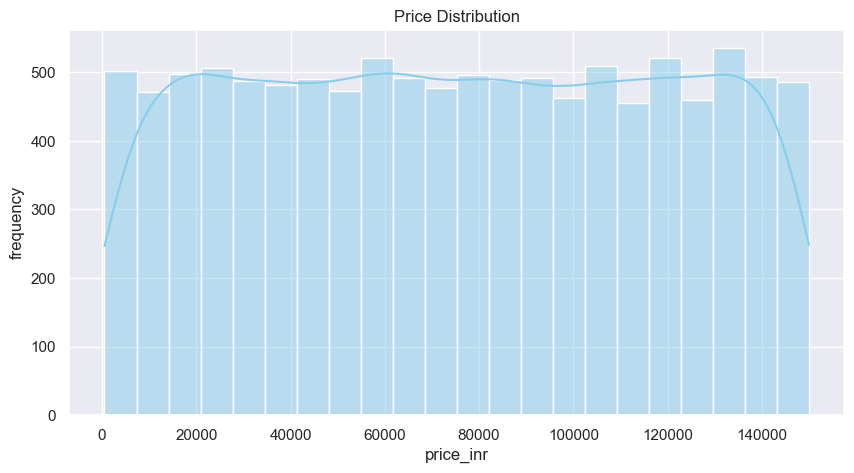

In [22]:
# Price Distribution
plt.figure(figsize=(10,5)) 
sns.histplot(df['price_inr'], kde=True, color='skyblue') 
plt.title('Price Distribution') 
plt.xlabel('price_inr') 
plt.ylabel('frequency')
plt.show() 

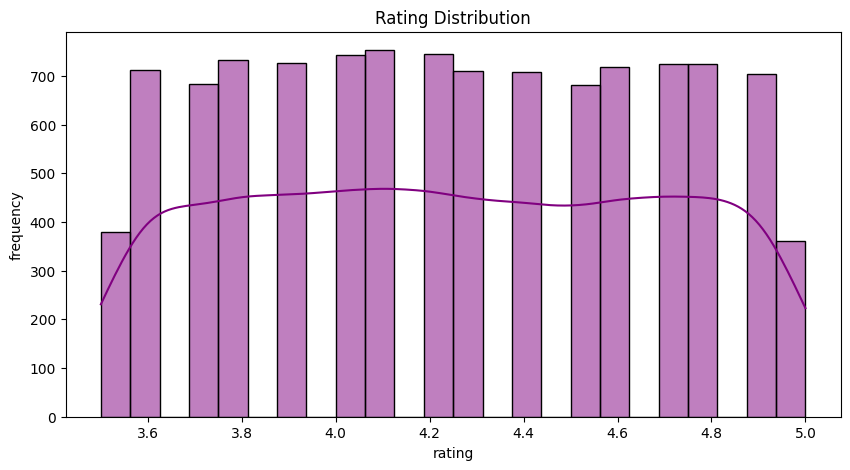

In [12]:
# Rating Distribution 
plt.figure(figsize=(10,5)) 
sns.histplot(df['rating'], kde=True, color='purple') 
plt.title('Rating Distribution') 
plt.xlabel('rating')
plt.ylabel('frequency') 
plt.show() 

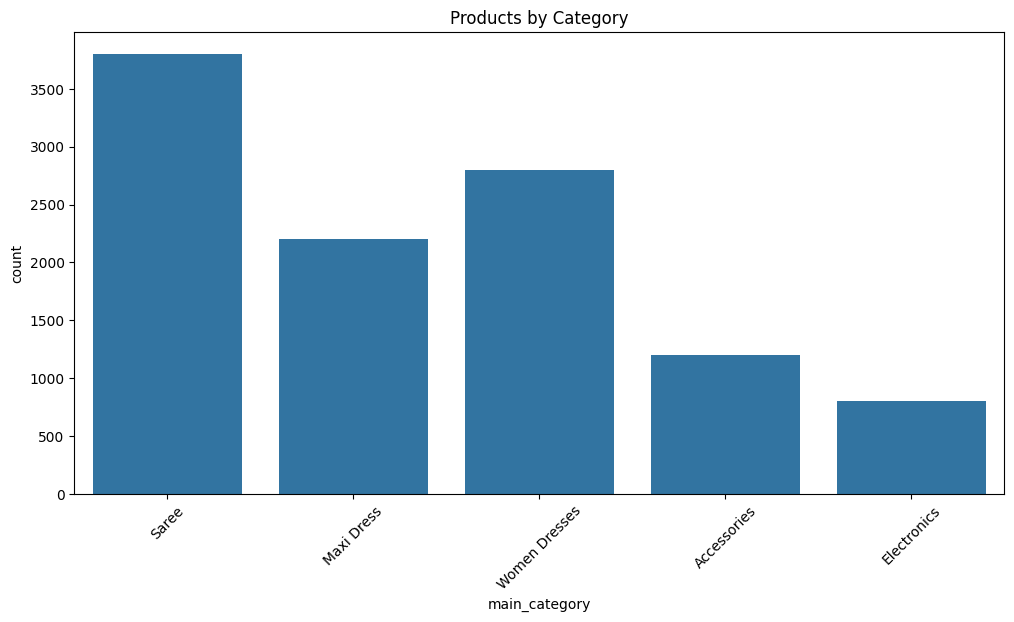

In [13]:
# Category Analysis
plt.figure(figsize=(12,6)) 
sns.countplot(data=df, x='main_category') 
plt.title('Products by Category') 
plt.xticks(rotation=45) 
plt.show() 
 

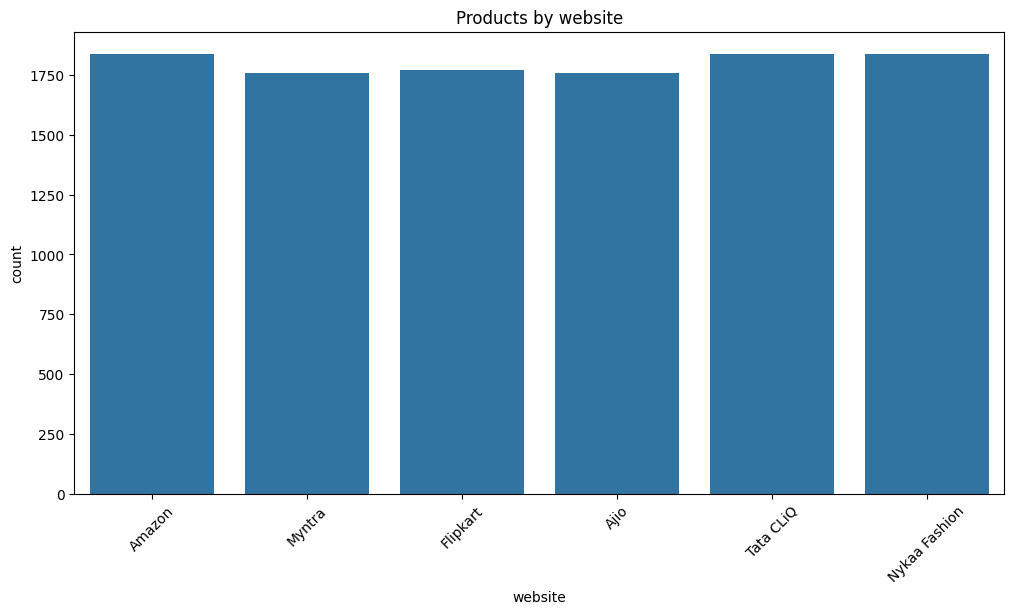

In [14]:
# Brand Analysis 
plt.figure(figsize=(12,6)) 
sns.countplot(data=df, x='website') 
plt.title('Products by website')
plt.xticks(rotation=45) 
plt.show() 
 

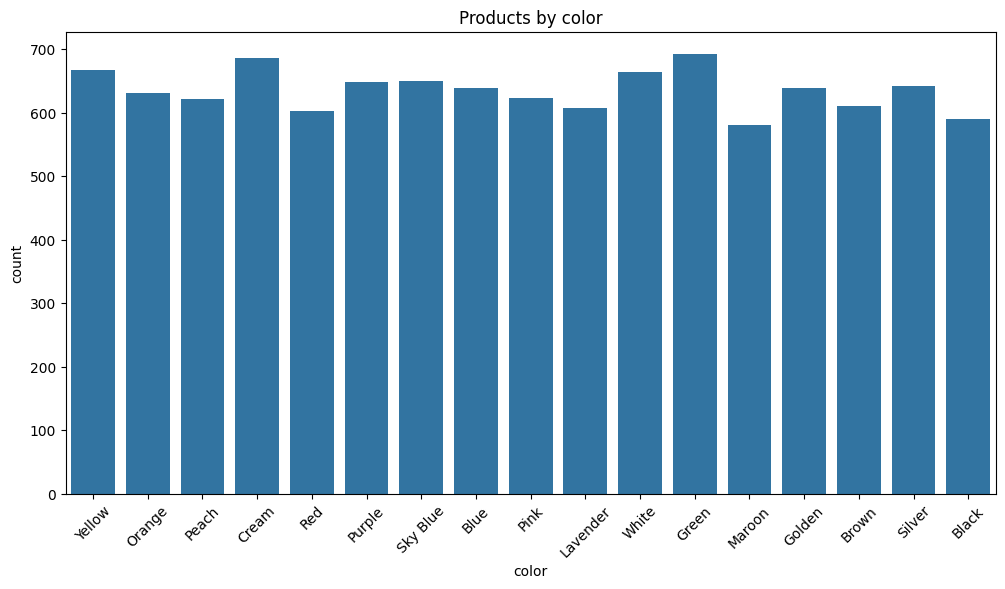

In [15]:
# Color Analysis 
plt.figure(figsize=(12,6)) 
sns.countplot(data=df, x='color') 
plt.title('Products by color') 
plt.xticks(rotation=45) 
plt.show() 
 

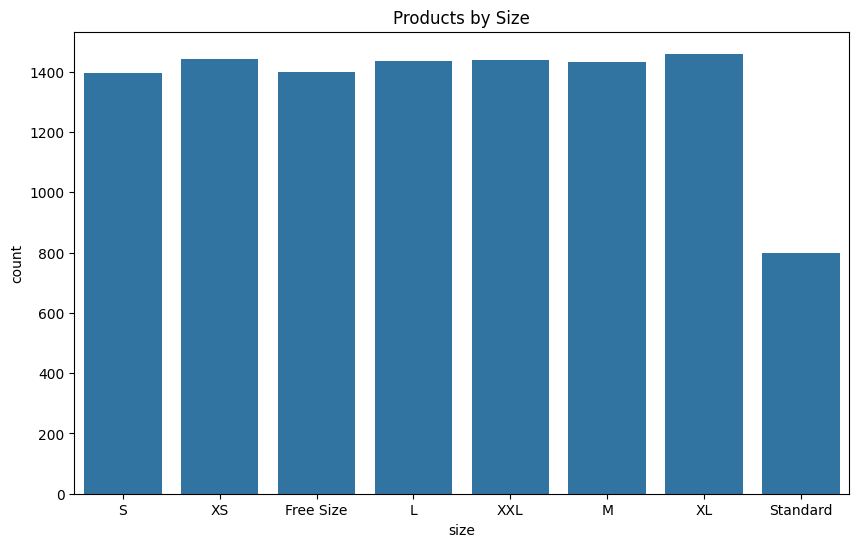

In [16]:
# Size Analysis
plt.figure(figsize=(10,6)) 
sns.countplot(data=df, x='size') 
plt.title('Products by Size') 
plt.show() 
 

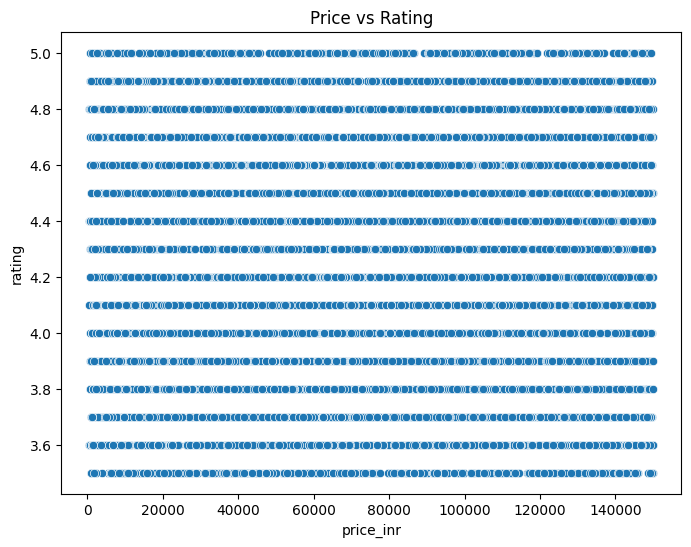

In [17]:
# Price vs Rating 
 
plt.figure(figsize=(8,6)) 
sns.scatterplot(data=df, x='price_inr', y='rating')
plt.title('Price vs Rating') 
plt.show() 

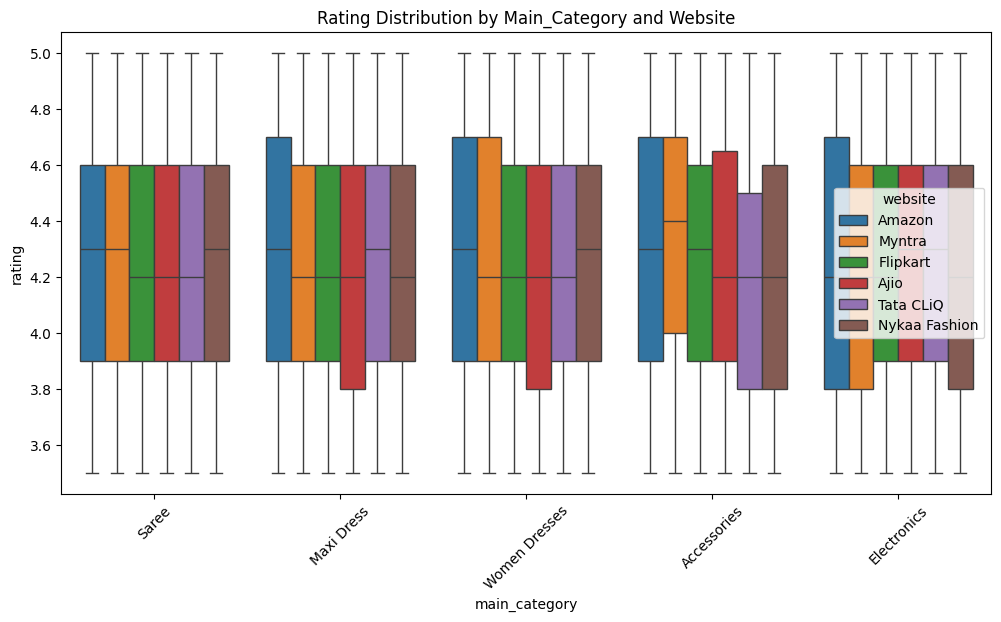

In [18]:
# Boxplot Analysis  
 
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='main_category', y='rating', hue='website') 
plt.title('Rating Distribution by Main_Category and Website') 
plt.xticks(rotation=45) 
plt.show() 
 

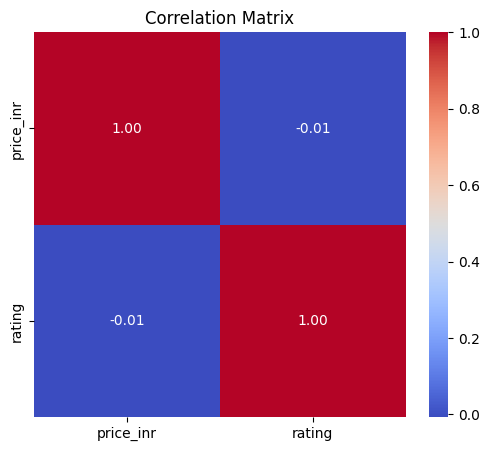

In [19]:
# Correlation Heatmap 
 
plt.figure(figsize=(6,5)) 
sns.heatmap(df[['price_inr', 'rating']].corr(),             
            annot=True,             
            cmap='coolwarm',             
            fmt='.2f') 
 
plt.title('Correlation Matrix') 
plt.show() 
 

In [20]:
# Top Products
 
top_products = df['product_name'].value_counts().head(10) 
 
print("\nTop Products:\n") 
print(top_products) 


Top Products:

product_name
Purple Smart Watches Model 184    1
Maroon Smart Watches Model 183    1
Blue Smart Watches Model 182      1
Orange Smart Watches Model 181    1
Purple Smart Watches Model 180    1
Pink Smart Watches Model 179      1
Brown Smart Watches Model 178     1
Maroon Smart Watches Model 177    1
Black Smart Watches Model 176     1
Brown Smart Watches Model 175     1
Name: count, dtype: int64


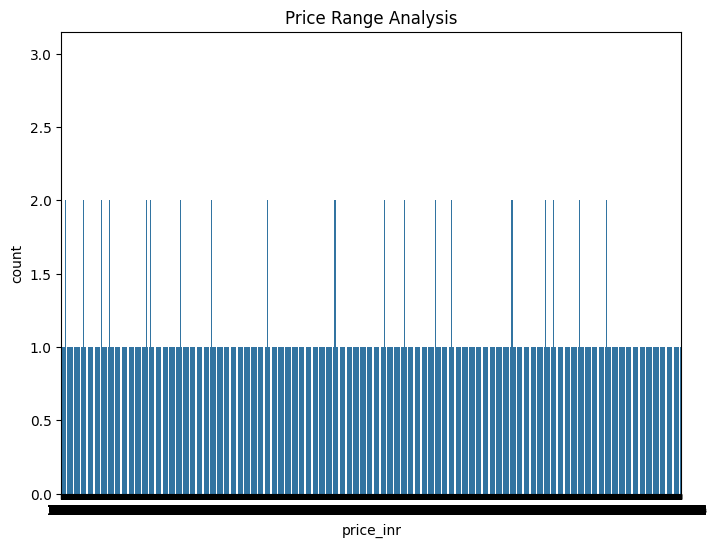

In [21]:
# Price Range Analysis 
price_bins =  [0, 50, 100, 150, 200] 
price_labels = ['Low', 'Medium', 'High', 'Premium'] 
 
df['Price Range'] = pd.cut(df['price_inr'],                            
                           bins=price_bins,                            
                           labels=price_labels)
plt.figure(figsize=(8,6)) 
sns.countplot(data=df, x='price_inr') 
plt.title('Price Range Analysis') 
plt.show() 
 

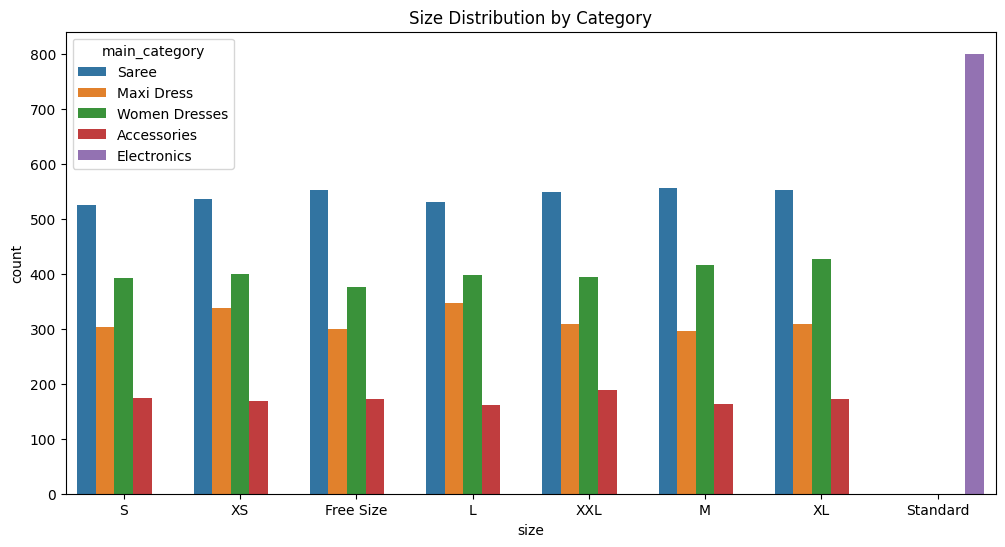

In [22]:
# Size vs Category
 
plt.figure(figsize=(12,6)) 
sns.countplot(data=df, x='size', hue='main_category') 
plt.title('Size Distribution by Category') 
plt.show() 
 

In [23]:
# Machine Learning 

In [24]:
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer 
from sklearn.impute import SimpleImputer 
from sklearn.metrics import mean_squared_error, r2_score 

In [25]:
# Outlier Removal using IQR
 
Q1 = df['rating'].quantile(0.25) 
Q3 = df['rating'].quantile(0.75) 
 
IQR = Q3 - Q1 
 
lower_bound = Q1 - 1.5 * IQR 
upper_bound = Q3 + 1.5 * IQR 
 
df = df[(df['rating'] >= lower_bound) &         
    (df['rating'] <= upper_bound)] 

In [26]:
# Feature Selection 

X = df.drop(columns=['rating']) 
 
# Remove unnecessary columns if present 
drop_cols = ['User ID', 'Product ID', 'Product Name'] 
 
for col in drop_cols:     
    if col in X.columns:         
        X = X.drop(columns=[col]) 
 
y = df['rating'] 
 

In [27]:
# Feature Engineering 
 
main_categorical_features = X.select_dtypes(include=['object']).columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns 
 
preprocessor = ColumnTransformer(    
    transformers=[         
        ('num', SimpleImputer(strategy='mean'), numeric_features),         
        ('cat', OneHotEncoder(handle_unknown='ignore'),          
         main_categorical_features)     
    ] ) 

In [28]:
# Train Test Split 
 
X_train, X_test, y_train, y_test = train_test_split(    
    X,     
    y,     
    test_size=0.2,     
    random_state=42 ) 

In [29]:
# Model Pipeline 
 
model = Pipeline(steps=[     
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42)) ]) 
 
# Train Model 
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [30]:
# Prediction & Evaluation 
 
y_pred = model.predict(X_test) 
 
mse = mean_squared_error(y_test, y_pred) 
r2 = r2_score(y_test, y_pred) 
 
print("\nModel Performance Before Tuning") 
print("Mean Squared Error:", mse) 
print("R2 Score:", r2) 


Model Performance Before Tuning
Mean Squared Error: 0.19820667592592592
R2 Score: -0.03748010487741915


In [ ]:
# Hyperparameter Tuning 
 
from sklearn.model_selection import GridSearchCV 
 
param_grid = {    
    'regressor__n_estimators': [100, 200],   
    'regressor__max_depth': [None, 10, 20],     
    'regressor__min_samples_split': [2, 5],     
    'regressor__min_samples_leaf': [1, 2] } 
 
grid_search = GridSearchCV(    
    model,     
    param_grid,    
    cv=5,     
    scoring='neg_mean_squared_error',     
    verbose=1,     
    n_jobs=-1 ) 
 
# Train Grid Search 
grid_search.fit(X_train, y_train) 

Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [30]:
# SALES CHATBOT

In [23]:
# System-Wide Dashboard Visualization Theme Matrix 
sns.set_theme(style="darkgrid") 
plt.rcParams.update({     
    'font.size': 10,     
    'axes.facecolor': '#17222A',     
    'figure.facecolor': '#0E141B',    
    'axes.labelsize': 11,     
    'axes.titlesize': 13,     
    'text.color': '#FFFFFF',     
    'axes.labelcolor': '#FFFFFF',     
    'xtick.color': '#FFFFFF',     
    'ytick.color': '#FFFFFF'
    }) 


# 1. DATA ACCESS OBJECT (DAO) LAYER [TECHNICAL ARCHITECTURE] 
class DataStorageAccessObject: 
    """ 
    Handles robust data extraction, safety validation, and normalizes column schemas. 
    Ensures structural compatibility between file variations without runtime failures. 
    """ 
    @staticmethod 
    def load_and_sanitize_catalog(file_path: str) -> pd.DataFrame: 
        if not os.path.exists(file_path): 
            raise FileNotFoundError(f"CRITICAL FAULT: Master inventory catalog data layer missing at '{file_path}'") 
         
        df = pd.read_csv(file_path) 
        # Standardize schema: clean whitespaces and cast headers to uniform lowercase 
        df.columns = df.columns.str.strip().str.lower() 
         
        # Safe structural mapping across common field alternatives
        df = df.rename(columns={ 
            'stock_available': 'stock', 
            'price_inr': 'price_inr', 
            'product_name': 'product_name' 
        }) 
         
        # Data Normalization Guardrails 
        if 'main_category' in df.columns: 
            df['main_category'] = df['main_category'].replace({ 
                'Saree': 'Saree', 
                'Maxi Dress': 'Maxi Dress' 
            }) 
             
        # Clean missing values and apply strict real-world data constraints 
        df['rating'] = pd.to_numeric(df['rating'], errors='coerce').fillna(4.0) 
        df['price_inr'] = pd.to_numeric(df['price_inr'], errors='coerce').fillna(0.0) 
        df['stock'] = pd.to_numeric(df['stock'], errors='coerce').fillna(10).astype(int) 
         
        if 'fabric' in df.columns: 
            df.loc[df['main_category'].isin(['Accessories', 'Electronics']), 'fabric'] = "Standard" 
            df['fabric'] = df['fabric'].fillna("Standard") 
             
        return df

#  2. MODEL LAYER 
class IntelligentInventoryEngine: 
    """ 
    Acts as the data framework source of truth. 
    Manages inventory metrics, renders performance plots, and performs AI-driven scoring evaluations. 
    """ 
    def __init__(self, validated_dataframe: pd.DataFrame): 
        self.df = validated_dataframe 
        self.rating_predictor_model = None 
        self._generate_system_kpis() 
        self._build_enterprise_dashboards() 
        self._train_predictive_intelligence() 
         
    def _generate_system_kpis(self): 
        self.total_skus = len(self.df) 
        self.total_stock = int(self.df['stock'].sum()) if 'stock' in self.df.columns else 0 
        self.global_mean_rating = round(self.df['rating'].mean(), 2) 
         
    def _build_enterprise_dashboards(self):
        print(" [Model Layer] Initializing background metrics visualization pipeline...") 
        fig, axes = plt.subplots(1, 2, figsize=(14, 5)) 
         
        sns.countplot(data=self.df, x='main_category',hue='main_category',legend=False,palette='cool', ax=axes[0], 
                      order=self.df['main_category'].value_counts().index) 
        axes[0].set_title('Product Volume Allocation Deep-Dive', color='#00DFD8') 
        axes[0].tick_params(axis='x', rotation=15) 
         
        sns.barplot(data=self.df, x='main_category', y='price_inr',hue='main_category', estimator=np.mean, 
                    errorbar=None, palette='plasma',legend=False, ax=axes[1]) 
        axes[1].set_title('Portfolio Mean Asset Capitalization (INR)', color='#FF3366') 
        axes[1].tick_params(axis='x', rotation=15) 
         
        plt.tight_layout() 
        plt.savefig('arch_category_metrics.png', dpi=150) 
        plt.close() 
         
        plt.figure(figsize=(7, 4.5)) 
        numeric_cols = [c for c in ['price_inr', 'rating', 'reviews_count', 'stock'] if c in 
self.df.columns] 
        if len(numeric_cols) > 1:
            sns.heatmap(self.df[numeric_cols].corr(), annot=True, cmap='viridis', fmt=".2f", cbar=True) 
            plt.title('Inter-Feature KPI Interaction Heatmap Matrix', color='#00DFD8') 
            plt.tight_layout() 
            plt.savefig('arch_correlation_matrix.png', dpi=150) 
            plt.close() 
 
    def _train_predictive_intelligence(self): 
        print(" [Model Layer] Initializing ML pipeline for predictive rating analysis...") 
        features = ['main_category', 'price_inr', 'stock', 'website'] 
        target = 'rating' 
         
        available_features = [f for f in features if f in self.df.columns] 
        if target in self.df.columns: 
            X = self.df[available_features] 
            y = self.df[target] 
             
            cat_cols = X.select_dtypes(include=['object']).columns.tolist() 
            num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist() 
             
            preprocessor = ColumnTransformer(transformers=[ 
                ('num', SimpleImputer(strategy='median'), num_cols), 
                ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols) 
            ]) 
             
            self.rating_predictor_model = Pipeline(steps=[ 
                ('preprocessor', preprocessor), 
                ('regressor', RandomForestRegressor(n_estimators=30, random_state=42,max_depth=8)) 
            ]) 
            self.rating_predictor_model.fit(X, y) 
            print(" [Model Layer] ML predictive pipeline training complete.") 
 
    def runtime_execution_query(self, category=None, color=None, fabric=None, 
website=None, size=None, max_budget=None, min_rating=None, sort_cheap=False, sort_top=False):
        working_set = self.df.copy() 
         
        if category: 
            working_set = working_set[working_set['main_category'].str.contains(category,case=False,na=False)] 
            
        if color: 
            working_set = working_set[working_set['color'].str.lower() == color.lower()] 
        if fabric and 'fabric' in working_set.columns: 
            working_set = working_set[working_set['fabric'].str.contains(fabric,case=False,na=False)] 
        if website: 
            working_set = working_set[working_set['website'].str.lower() == website.lower()] 
        if size and 'size' in working_set.columns: 
            working_set = working_set[working_set['size'].str.lower() == size.lower()] 
        if max_budget: 
            working_set = working_set[working_set['price_inr'] <= max_budget] 
        if min_rating: 
            working_set = working_set[working_set['rating'] >= min_rating] 
             
        if sort_cheap: 
            working_set = working_set.sort_values(by='price_inr', ascending=True) 
        elif sort_top: 
            working_set = working_set.sort_values(by='rating', ascending=False) 
             
        return working_set.head(6)

# 3. CONTROLLER LAYER 

class StatefulAgentIntentController: 
    """ 
    Decodes contextual intent structures, extracts numerical parameters like budget constraints 
    using regex engines, and formats responsive customer conversion packets. 
    """ 
    
    def __init__(self, data_engine: IntelligentInventoryEngine):
        self.engine = data_engine
    def parse_and_route_query(self, user_text: str) -> str:
        tokens = user_text.lower().strip()
        print("USER:",user_text)
        print("TOKENS:",tokens)
       

        # Feature: Welcome Greeting Layer Detection
        if any(greet in tokens for greet in ["hi", "hello", "hey", "greetings", "good morning", "good afternoon"]):
            return("**Hello! Welcome valued customer to our AI Retail Assistant!**\n\n"
            f"I am connected live to our product registry framework containing **{self.engine.total_skus:,}** active catalog entries.\n\n"
            "How can I help you browse today?")
             
           
            
        
        color_match = None 
        fabric_match = None 
        website_match = None 
        size_match = None 
        min_rating = None 
        sort_by_cheapest = False 
        sort_by_top_rated = False
        budget_limit=None
        matched_vertical=None
         
        # Color Detection 
        for color in ["yellow", "orange", "peach", "cream", "red", "blue", "green", "pink", "purple", "black", "white", "grey"]: 
            if color in tokens: 
                color_match = color 
                break 
                 
        # Fabric Detection 
        for fabric in ["organza", "silk", "net", "rayon", "chiffon", "cotton", "linen"]: 
            if fabric in tokens:
                fabric_match = fabric 
                break 
                 
        # Website Detection 
        for website in ["amazon", "flipkart", "myntra", "ajio", "tata cliq", "nykaa fashion"]: 
            if website in tokens: 
                website_match = website 
                break 
                 
        # Size Detection 
        size_pattern = re.search(r"\b(xs|s|m|l|xl|xxl|free size)\b", tokens) 
        if size_pattern: 
            size_match = size_pattern.group(1) 
             
        # Rating Extraction Engine 
        rating_pattern = re.search(r"(?:rating|score)\s*(?:above|over|>)?\s*(\d(?:\.\d)?)", tokens) 
        if rating_pattern: 
            min_rating = float(rating_pattern.group(1)) 
        elif "top rated" in tokens or "best rated" in tokens:
            sort_by_top_rated = True 
             
        # Sorting Modifiers 
        if "cheapest" in tokens or "lowest price" in tokens: 
            sort_by_cheapest = True 
             
        # Numerical Budget Extraction Engine 
        budget_limit = None 
        money_matches = re.findall(r'(?:rs|inr|under|below)\s*?(\d+)', tokens) 
        if money_matches: 
            try: 
                budget_limit = float(money_matches[0]) 
            except ValueError: 
                budget_limit = None 
                 
        # Dynamic Category Contextual Mapping Engine 
        matched_vertical = None 
        if any(w in tokens for w in ["saree", "banarasi", "kanjivaram", "organza"]): 
            matched_vertical = "Saree" 
        elif any(w in tokens for w in ["maxi", "gown"]): 
            matched_vertical = "Maxi Dress" 
        elif any(w in tokens for w in ["dress", "kurti", "lehenga", "suit", "jeans", "tops", "t-shirts", "hoodies"]): 
            matched_vertical = "Women Dresses" 
        elif any(w in tokens for w in ["jewellery", "watches", "bags", "sandals", "heels", "shoes"]): 
            matched_vertical = "Accessories" 
        elif any(w in tokens for w in ["laptops", "phones", "earbuds", "smart watches"]): 
            matched_vertical = "Electronics" 
             
        # Request Engine Query Results 
        matched_records = self.engine.runtime_execution_query( 
            category=matched_vertical, color=color_match, fabric=fabric_match, 
            website=website_match, size=size_match, max_budget=budget_limit, 
            min_rating=min_rating, sort_cheap=sort_by_cheapest, sort_top=sort_by_top_rated ) 
         
        if matched_records.empty: 
            return f"No items match your specific query criteria in our store. Try adjusting keywords." 
             
        # Convert pandas results to a markdown readable response payload 
        response_accumulator = f"**System Query Search Results (Matches Found: {len(matched_records)})**\n\n" 
        for _, item in matched_records.iterrows(): 
            fabric_str = f" | Fabric: {item['fabric']}" if 'fabric' in item and pd.notna(item['fabric']) else "" 
            response_accumulator += ( 
                f"**{item['product_name']}**\n" 
                f" Category: `{item['main_category']}`({item['subcategory']})| Color: {item['color']}{fabric_str}\n" 
                f" Price: **INR {item['price_inr']:,}**| Rating: {item['rating']} | Store: *{item['website']}*\n" 
                f" Link: [View Product]({item['product_link']})\n" 
                f"--------------------------------------------------\n"
            ) 
        return response_accumulator
# 4. VIEW (GRADIO INTERFACE UI) LAYER
class CyberpunkNeonDashboardView: 
    def __init__(self, architecture_controller: StatefulAgentIntentController): 
        self.controller = architecture_controller 
        self._assemble_ui_workspace() 
         
    def _assemble_ui_workspace(self): 
        with gr.Blocks()as self.workspace_root: 
            gr.Markdown("<h1 style='text-align: center; color: #00DFD8;'>FASHION ANALYTICS CHATBOT HUB</h1>") 
             
            with gr.Row(): 
                with gr.Column(scale=2): 
                    gr.Markdown("### Interactive Store Agent Terminal") 
                    live_chat_terminal = gr.Chatbot(label="System Response Window", height=450) 
                    input_text_field = gr.Textbox(placeholder="Inquire across database rows... (e.g.,'Show me Yellow Banarasi Saree under 75000')", label="Client Request String") 
                    fire_execution_btn = gr.Button("Transmit Transaction Request") 
                     
                with gr.Column(scale=3): 
                    gr.Markdown("### Real-Time Analytics Pipeline Monitoring Visualization") 
                    gr.Image("arch_category_metrics.png", label="Channel Ingestion Allocation Metrics") 
                    gr.Image("arch_correlation_matrix.png", label="Inter-Feature KPI Interaction Heatmap Matrix") 
                     
            # Route UI Pipeline Interactivity Hooks 
            fire_execution_btn.click(fn=self._transaction_routing_pipeline, inputs=[input_text_field, live_chat_terminal], outputs=[input_text_field, live_chat_terminal]) 
            input_text_field.submit(fn=self._transaction_routing_pipeline, inputs=[input_text_field, live_chat_terminal], outputs=[input_text_field, live_chat_terminal]) 
             
    def _transaction_routing_pipeline(self, user_msg, chat_history): 
        if not user_msg.strip(): 
            return "", chat_history
        if chat_history is None:
            chat_history=[]
        try:    
            agent_reply = self.controller.parse_and_route_query(user_msg)
            chat_history.append({"role":"user","content":user_msg})
            chat_history.append({"role":"assistant","content":agent_reply})
        except Exception as e:     
            chat_history.append({"role":"assistant","content":f"Error:{str(e)}"})
        return "", chat_history 
       
 
    def run_production_server(self): 
        print(" [System Deployment] Activating service listener network stack blocks...") 
       
        self.workspace_root.launch(theme=gr.themes.Monochrome(),share=True, prevent_thread_lock=True) 
 

# 5. LIFE-CYCLE RUN INITIALIZATION NODE 

if __name__ == "__main__": 
    sanitized_df = DataStorageAccessObject.load_and_sanitize_catalog("all_in_one_fashion_analysis.csv") 
    engine = IntelligentInventoryEngine(sanitized_df) 
    controller = StatefulAgentIntentController(engine) 
    view = CyberpunkNeonDashboardView(controller) 

# Patched launch instruction 
view.run_production_server()
        
        
        


       
        

 [Model Layer] Initializing background metrics visualization pipeline...
 [Model Layer] Initializing ML pipeline for predictive rating analysis...
 [Model Layer] ML predictive pipeline training complete.
 [System Deployment] Activating service listener network stack blocks...
* Running on local URL:  http://127.0.0.1:7866
* Running on public URL: https://37f626deb96a042a18.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
